# Keyword Extraction Methods — Comparative Analysis

Comparing **RAKE**, **YAKE**, **KeyBERT**, and **LLM** on ICLR papers.

- **Train set**: papers until 2024
- **Test set**: papers from 2025 only

Analysis consists of:
1. Basic statistics (counts, lengths, vocabulary size)
2. Overlap & uniqueness across methods
3. Normalization impact (reduction ratio per method)
4. Concept frequency distributions
5. Semantic diversity (embedding-based)
6. Coverage on test set (how well train concepts cover 2025)
7. Top concepts per method

## Setup

In [ ]:
%pip uninstall  -y matplotlib-venn

In [ ]:
import ast
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

In [2]:
COLORS = {
    "rake": "darkorange",
    "yake": "mediumseagreen",
    "keybert": "indianred",
    "llm": "steelblue",
}

## Load Data

In [3]:
# Paths 
BASE = Path("../data/interim")
METHODS = ["rake", "yake", "keybert", "llm"]
SPLITS = ["until_2024", "only_2025"]

RAW_TEMPLATE = "{method}/raw_concepts_{split}.csv"
NORM_TEMPLATE = "{method}/normalized_concepts_{split}.csv"
CLUSTER_TEMPLATE = "{method}/clusters_{split}.csv"

def path_for(template: str, method: str, split: str) -> Path:
    return BASE / template.format(method=method, split=split)

# Parse concept list stored as string
def parse_concepts(val):
    return [str(concept).strip() for concept in ast.literal_eval(val) if concept]

In [4]:
# Load everything into a structured dict
data = {}

for method in METHODS:
    data[method] = {}
    for split in SPLITS:
        entry = {}
        raw_path = path_for(RAW_TEMPLATE, method, split)
        norm_path = path_for(NORM_TEMPLATE, method, split)
        cluster_path = path_for(CLUSTER_TEMPLATE, method, split)

        if raw_path.exists():
            df_raw = pd.read_csv(raw_path)
            df_raw["_concepts"] = df_raw["raw_concepts"].map(parse_concepts)
            entry["raw"] = df_raw
        else:
            print(f"Missing: {raw_path}")
            entry["raw"] = None

        if norm_path.exists():
            df_norm = pd.read_csv(norm_path)
            df_norm["_norm_concepts"] = df_norm["normalized_concepts"].map(parse_concepts)
            entry["norm"] = df_norm
        else:
            print(f"Missing: {norm_path}")
            entry["norm"] = None

        if cluster_path.exists():
            entry["clusters"] = pd.read_csv(cluster_path)
        else:
            entry["clusters"] = None

        data[method][split] = entry

print("Data loaded")

Data loaded


## Basic Statistics

In [5]:
def compute_basic_stats(data: dict, split: str) -> pd.DataFrame:
    """Compute basic statistics per method for a given split."""
    rows = []
    for method in METHODS:
        entry = data[method][split]
        if entry["raw"] is None:
            continue

        all_raw = []
        for lst in entry["raw"]["_concepts"]:
            all_raw.extend(lst)

        all_norm = []
        if entry["norm"] is not None:
            for lst in entry["norm"]["_norm_concepts"]:
                all_norm.extend([c for c in lst if c])

        n_docs = len(entry["raw"])
        n_total = len(all_raw)
        n_unique_raw = len(set(all_raw))
        avg_per_doc = n_total / max(n_docs, 1)
        avg_words = np.mean([len(c.split()) for c in all_raw]) if all_raw else 0
        avg_chars = np.mean([len(c) for c in all_raw]) if all_raw else 0
        n_unique_norm = len(set(all_norm)) if all_norm else None
        reduction = (
            (1 - n_unique_norm / max(n_unique_raw, 1)) * 100
            if n_unique_norm is not None else None
        )

        rows.append({
            "Method": method.upper(),
            "Documents": n_docs,
            "Total concepts": n_total,
            "Unique raw": n_unique_raw,
            "Unique normalized": n_unique_norm,
            "Reduction %": f"{reduction:.1f}" if reduction is not None else "—",
            "Avg per doc": f"{avg_per_doc:.1f}",
            "Avg words": f"{avg_words:.1f}",
            "Avg chars": f"{avg_chars:.1f}",
        })

    return pd.DataFrame(rows)


print("TRAIN SET (until 2024)")
stats_train = compute_basic_stats(data, "until_2024")
display(stats_train)

print("TEST SET (2025 only)")
stats_test = compute_basic_stats(data, "only_2025")
display(stats_test)

TRAIN SET (until 2024)


,Method,Documents,Total concepts,Unique raw,Unique normalized,Reduction %,Avg per doc,Avg words,Avg chars
0,RAKE,7646,76460,67274,50922,24.3,10.0,3.2,28.1
1,YAKE,7646,76460,54702,36005,34.2,10.0,2.4,20.1
2,KEYBERT,7646,76460,67634,57145,15.5,10.0,2.5,19.8
3,LLM,7646,75710,54968,47461,13.7,9.9,2.6,23.3


TEST SET (2025 only)


,Method,Documents,Total concepts,Unique raw,Unique normalized,Reduction %,Avg per doc,Avg words,Avg chars
0,RAKE,3703,37030,34144,28538,16.4,10.0,3.3,29.4
1,YAKE,3703,37030,28297,20441,27.8,10.0,2.4,20.1
2,KEYBERT,3703,37030,33547,30284,9.7,10.0,2.5,20.0
3,LLM,3703,36755,30117,27125,9.9,9.9,2.7,23.8


## Concept Length Distributions

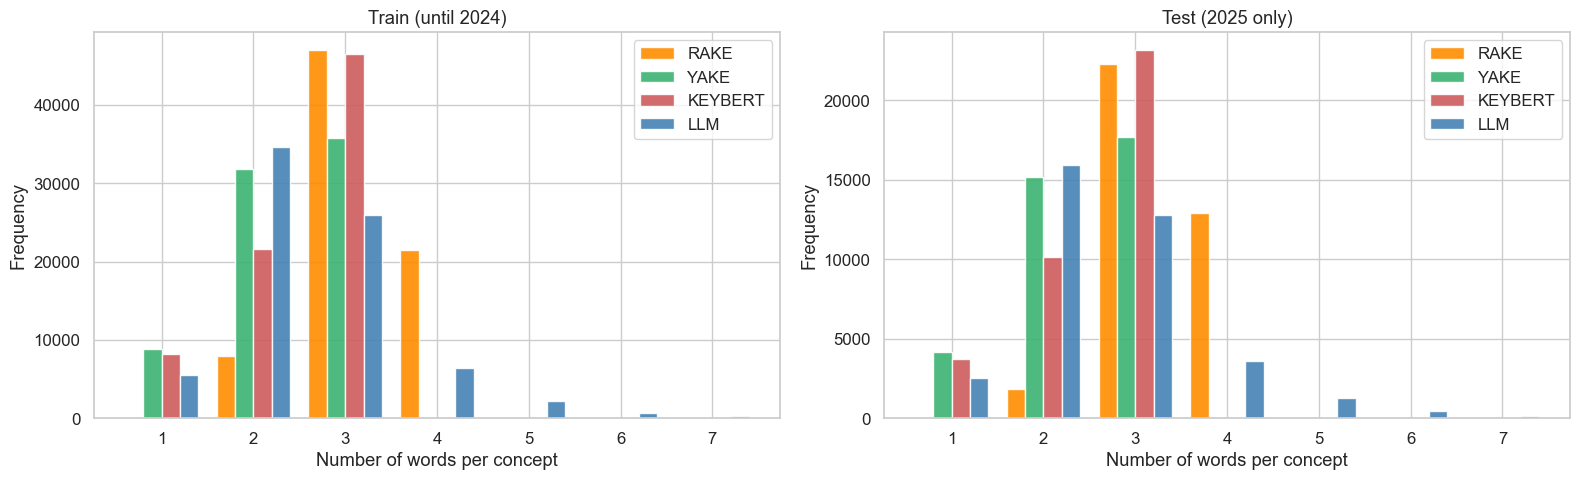

In [6]:
import re as _re

_BINS = list(range(1, 8))  # 1-7 words

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, split, title in zip(
    axes, SPLITS, ["Train (until 2024)", "Test (2025 only)"]
):
    counts_per_method = {}
    for method in METHODS:
        entry = data[method][split]
        if entry["raw"] is None:
            continue
        all_concepts = []
        for lst in entry["raw"]["_concepts"]:
            all_concepts.extend(lst)
        word_counts = [min(len(c.split()), 7) for c in all_concepts]
        cnt = Counter(word_counts)
        counts_per_method[method] = [cnt.get(b, 0) for b in _BINS]

    x = np.arange(len(_BINS))
    n_methods = len(counts_per_method)
    width = 0.8 / n_methods
    for i, (method, counts) in enumerate(counts_per_method.items()):
        offset = (i - n_methods / 2 + 0.5) * width
        ax.bar(x + offset, counts, width,
               label=method.upper(), color=COLORS[method],
               edgecolor="white", alpha=0.9)

    ax.set_xlabel("Number of words per concept")
    ax.set_ylabel("Frequency")
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels([str(b) for b in _BINS])
    ax.legend()

plt.tight_layout()
plt.savefig("images/keyword_analysis/01_concept_length_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


## Vocabulary Overlap Between Methods

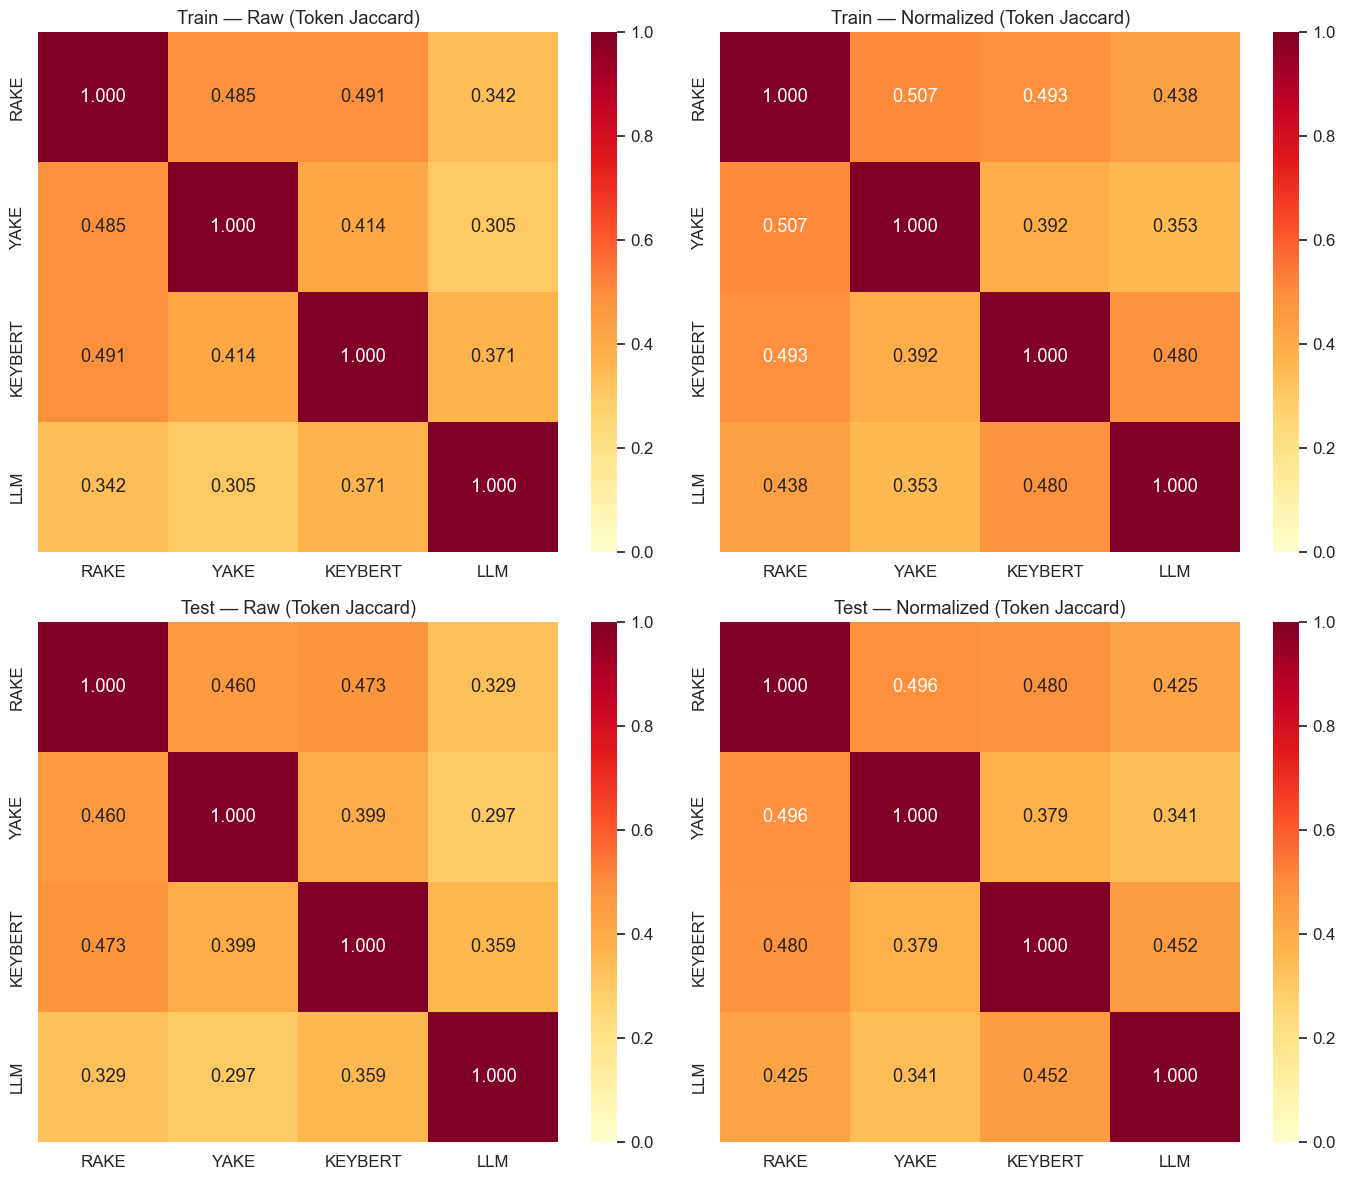

In [7]:
import re as _re2

_STOPWORDS = {"a", "an", "the", "of", "in", "for", "on", "with", "and", "or"}

def _concept_tokens(phrase):
    return {w for w in _re2.split(r"[\s\-_]+", phrase.lower())
            if w and w not in _STOPWORDS}


def get_unique_concepts(data: dict, method: str, split: str, normalized: bool = False) -> set:
    """Get set of unique concepts for a method/split."""
    entry = data[method][split]
    if normalized and entry["norm"] is not None:
        all_c = []
        for lst in entry["norm"]["_norm_concepts"]:
            all_c.extend([c for c in lst if c])
        return set(all_c)
    elif entry["raw"] is not None:
        all_c = []
        for lst in entry["raw"]["_concepts"]:
            all_c.extend(lst)
        return set(c.lower().strip() for c in all_c)
    return set()


def _token_vocab(data, method, split, normalized):
    """Flatten all concept tokens into one set for a method/split."""
    concepts = get_unique_concepts(data, method, split, normalized)
    token_set = set()
    for c in concepts:
        token_set.update(_concept_tokens(c))
    return token_set


def plot_overlap_heatmap(data: dict, split: str, normalized: bool, ax=None):
    """Token-Jaccard similarity heatmap between all method pairs."""
    vocab = {m: _token_vocab(data, m, split, normalized) for m in METHODS}
    available = [m for m in METHODS if vocab[m]]

    n = len(available)
    jaccard = np.zeros((n, n))
    for i, m1 in enumerate(available):
        for j, m2 in enumerate(available):
            inter = len(vocab[m1] & vocab[m2])
            union = len(vocab[m1] | vocab[m2])
            jaccard[i, j] = inter / max(union, 1)

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        jaccard,
        xticklabels=[m.upper() for m in available],
        yticklabels=[m.upper() for m in available],
        annot=True, fmt=".3f", cmap="YlOrRd", vmin=0, vmax=1, ax=ax,
    )
    kind = "Normalized" if normalized else "Raw"
    ax.set_title(f"Token Jaccard ({kind})")


fig, axes = plt.subplots(2, 2, figsize=(14, 12))

plot_overlap_heatmap(data, "until_2024", normalized=False, ax=axes[0, 0])
axes[0, 0].set_title("Train — Raw (Token Jaccard)")
plot_overlap_heatmap(data, "until_2024", normalized=True, ax=axes[0, 1])
axes[0, 1].set_title("Train — Normalized (Token Jaccard)")
plot_overlap_heatmap(data, "only_2025", normalized=False, ax=axes[1, 0])
axes[1, 0].set_title("Test — Raw (Token Jaccard)")
plot_overlap_heatmap(data, "only_2025", normalized=True, ax=axes[1, 1])
axes[1, 1].set_title("Test — Normalized (Token Jaccard)")

plt.tight_layout()
plt.savefig("images/keyword_analysis/02_method_overlap_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


## Top Concepts Per Method

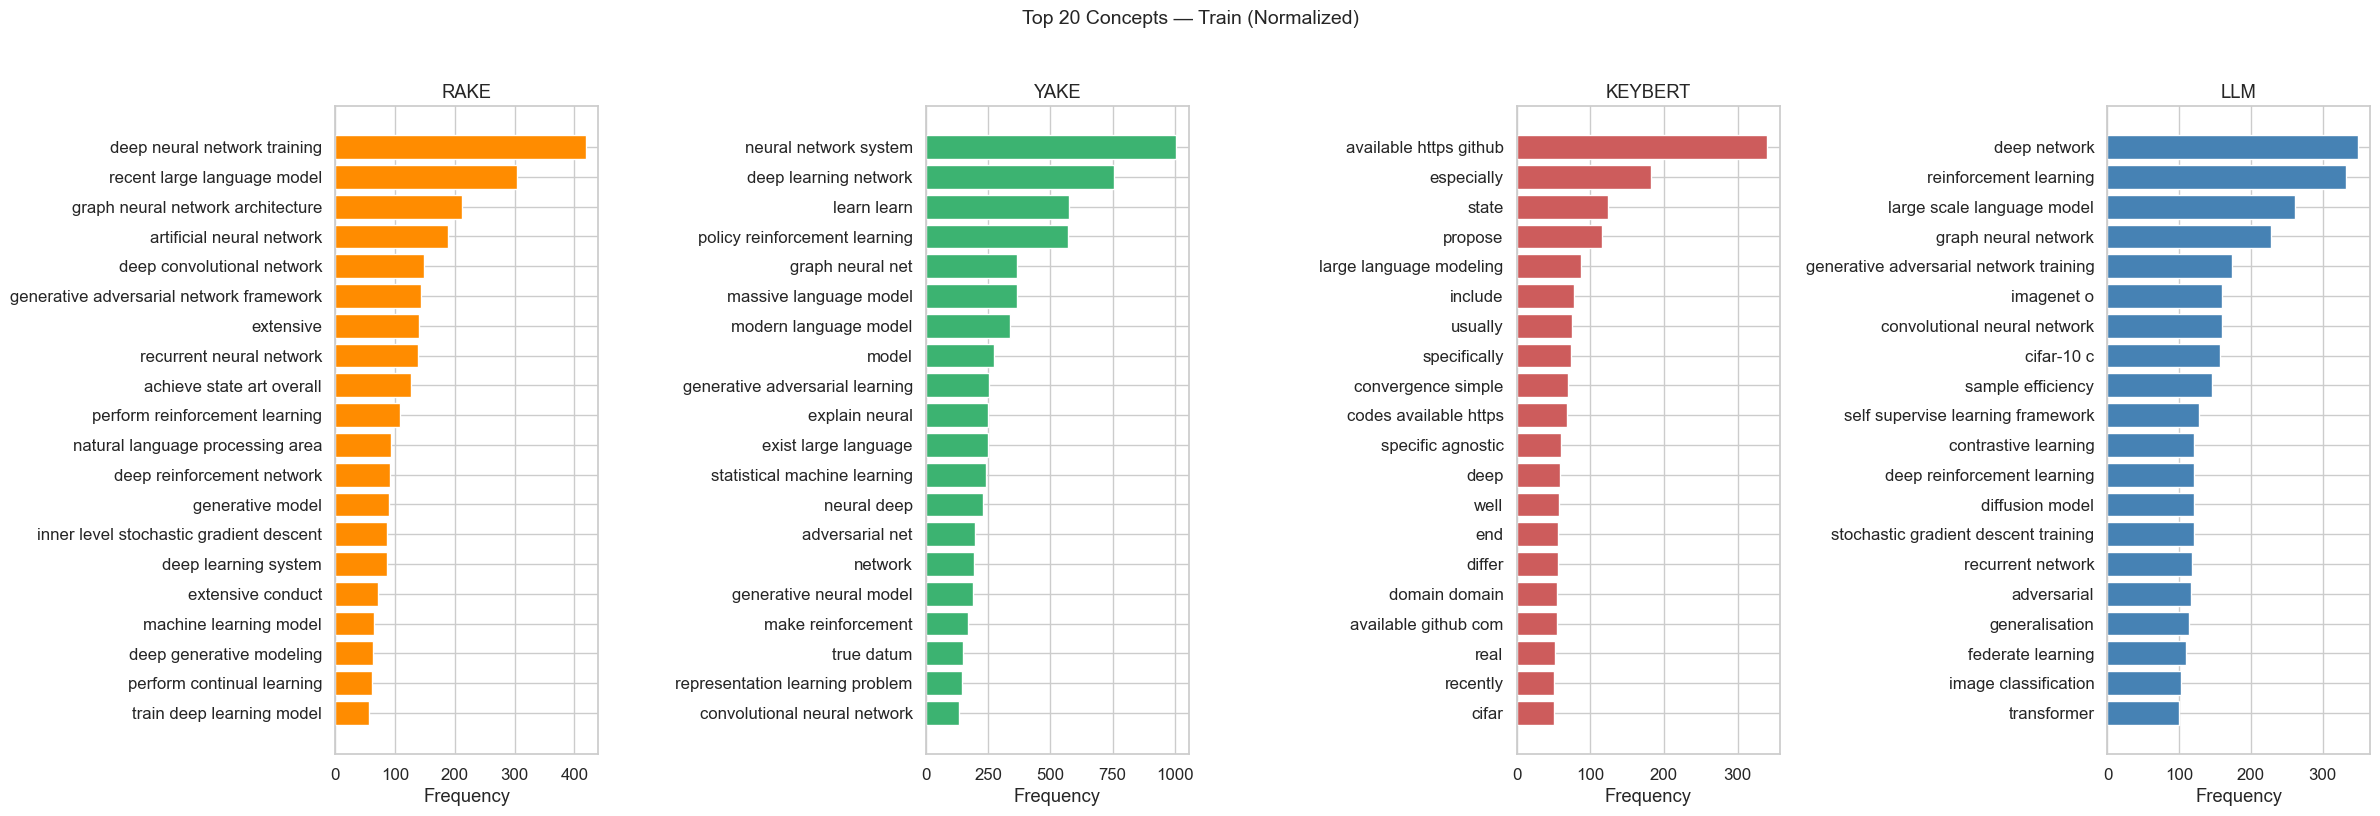

In [8]:
def plot_top_concepts(data, split, normalized=True, top_n=20):
    """Bar charts of top concepts per method."""
    n_methods = len(METHODS)
    fig, axes = plt.subplots(1, n_methods, figsize=(6 * n_methods, 8))
    if n_methods == 1:
        axes = [axes]

    for ax, method in zip(axes, METHODS):
        entry = data[method][split]
        if normalized and entry["norm"] is not None:
            all_c = []
            for lst in entry["norm"]["_norm_concepts"]:
                all_c.extend([c for c in lst if c])
        elif entry["raw"] is not None:
            all_c = []
            for lst in entry["raw"]["_concepts"]:
                all_c.extend(lst)
            all_c = [c.lower().strip() for c in all_c]
        else:
            continue

        freq = Counter(all_c).most_common(top_n)
        concepts = [c for c, _ in freq][::-1]
        counts = [n for _, n in freq][::-1]

        ax.barh(concepts, counts, color=COLORS[method], edgecolor="white")
        ax.set_title(f"{method.upper()}")
        ax.set_xlabel("Frequency")

    kind = "Normalized" if normalized else "Raw"
    split_label = "Train" if "2024" in split else "Test"
    plt.suptitle(f"Top {top_n} Concepts — {split_label} ({kind})", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(
        f"images/keyword_analysis/03_top_concepts_{split_label.lower()}_{kind.lower()}.png",
        dpi=150, bbox_inches="tight",
    )
    plt.show()


plot_top_concepts(data, "until_2024", normalized=True, top_n=20)

## Normalization Impact — Cluster Size Distribution

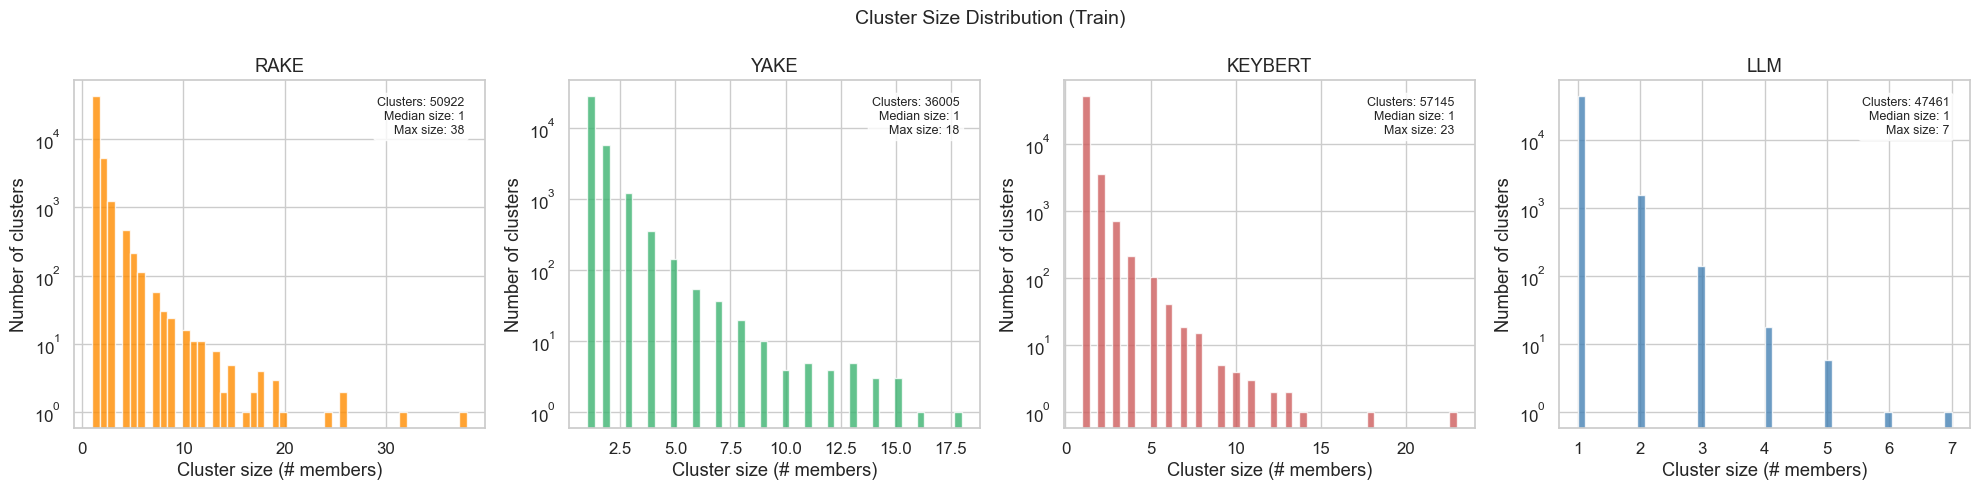

In [9]:
fig, axes = plt.subplots(1, len(METHODS), figsize=(5 * len(METHODS), 5))
if len(METHODS) == 1:
    axes = [axes]

for ax, method in zip(axes, METHODS):
    entry = data[method]["until_2024"]
    if entry["clusters"] is None:
        ax.set_title(f"{method.upper()} — no clusters")
        continue

    cluster_df = entry["clusters"]
    cluster_sizes = cluster_df.groupby("cluster_id")["member_concept"].nunique()

    ax.hist(cluster_sizes.values, bins=50, color=COLORS[method],
            edgecolor="white", alpha=0.8)
    ax.set_xlabel("Cluster size (# members)")
    ax.set_ylabel("Number of clusters")
    ax.set_title(f"{method.upper()}")
    ax.set_yscale("log")

    # Stats annotation
    stats_text = (
        f"Clusters: {len(cluster_sizes)}\n"
        f"Median size: {cluster_sizes.median():.0f}\n"
        f"Max size: {cluster_sizes.max()}"
    )
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes,
            va="top", ha="right", fontsize=9,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.suptitle("Cluster Size Distribution (Train)", fontsize=14)
plt.tight_layout()
plt.savefig("images/keyword_analysis/04_cluster_sizes.png", dpi=150, bbox_inches="tight")
plt.show()

## Train-Test Coverage

How well do concepts from **train** (until 2024) cover **test** (2025)?
This measures whether a method discovers stable, generalizable concepts.

In [10]:
def compute_coverage(data, method, normalized=True):
    """What fraction of test concepts also appear in train."""
    train_vocab = get_unique_concepts(data, method, "until_2024", normalized)
    test_vocab = get_unique_concepts(data, method, "only_2025", normalized)
    if not test_vocab:
        return {"coverage": 0, "train_size": len(train_vocab), "test_size": 0,
                "overlap": 0, "new_in_test": 0}
    overlap = train_vocab & test_vocab
    new = test_vocab - train_vocab
    return {
        "coverage": len(overlap) / len(test_vocab),
        "train_size": len(train_vocab),
        "test_size": len(test_vocab),
        "overlap": len(overlap),
        "new_in_test": len(new),
    }

In [11]:
coverage_rows = []
for method in METHODS:
    for norm_flag, label in [(False, "Raw"), (True, "Normalized")]:
        cov = compute_coverage(data, method, normalized=norm_flag)
        coverage_rows.append({
            "Method": method.upper(),
            "Type": label,
            **cov,
        })

coverage_df = pd.DataFrame(coverage_rows)
coverage_df["coverage_pct"] = (coverage_df["coverage"] * 100).round(1)
display(coverage_df[["Method", "Type", "train_size", "test_size", "overlap", "new_in_test", "coverage_pct"]])

,Method,Type,train_size,test_size,overlap,new_in_test,coverage_pct
0,RAKE,Raw,67274,34144,2141,32003,6.3
1,RAKE,Normalized,50922,28538,5437,23101,19.1
2,YAKE,Raw,51660,27082,4456,22626,16.5
3,YAKE,Normalized,36005,20441,5739,14702,28.1
4,KEYBERT,Raw,67634,33547,2256,31291,6.7
5,KEYBERT,Normalized,57145,30284,5198,25086,17.2
6,LLM,Raw,50874,28463,4682,23781,16.4
7,LLM,Normalized,47461,27125,5314,21811,19.6


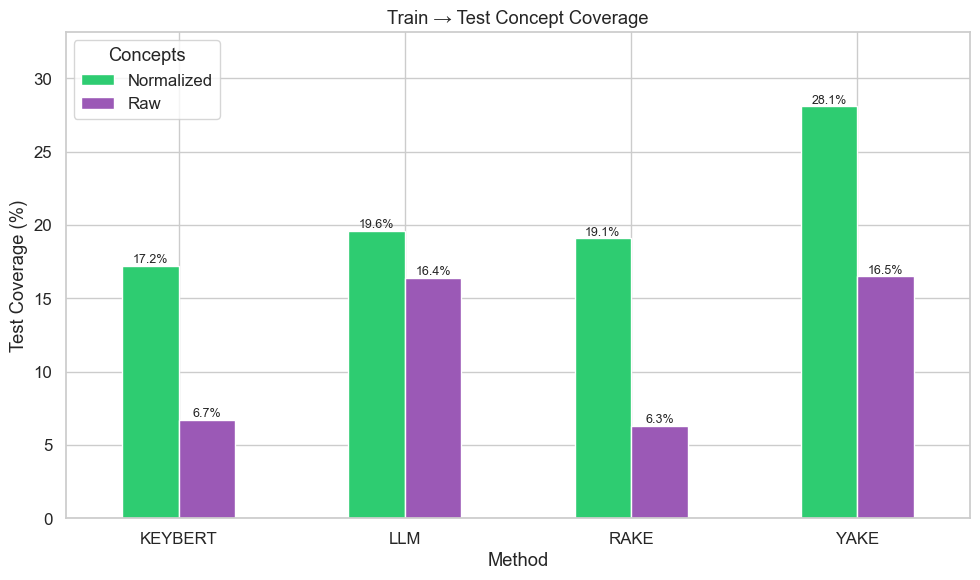

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
pivot = coverage_df.pivot(index="Method", columns="Type", values="coverage_pct")
pivot.plot(kind="bar", ax=ax, color=["#2ecc71", "#9b59b6"], edgecolor="white")
ax.set_ylabel("Test Coverage (%)")
ax.set_title("Train → Test Concept Coverage")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Concepts")
ax.set_ylim(0, coverage_df["coverage_pct"].max() * 1.18)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=9)
plt.tight_layout()
plt.savefig("images/keyword_analysis/05_train_test_coverage.png", dpi=150, bbox_inches="tight")
plt.show()


## Conclusions


**Concept Length Distribution**
- All four methods produce **mostly 2–3 word phrases**, with 2-word concepts dominating across methods and splits.  
- **RAKE** has a heavier tail at 4–5+ words, reflecting its tendency to extract longer noun phrases.  
- **YAKE** and **KeyBERT** concentrate strongly at 2 words; the LLM output is slightly more balanced across 2–4 words.  
- The pattern is stable between the train and test splits, suggesting consistent extraction behaviour regardless of year.

**Vocabulary Overlap (Token Jaccard)**
- Switching from exact-string Jaccard to **token-level Jaccard** reveals substantially higher cross-method overlap than exact matching alone would suggest, because different methods may phrase the same concept differently while sharing key tokens.  
- **YAKE ↔ KeyBERT** and **YAKE ↔ LLM** tend to show the highest token overlap on normalized vocabularies, while **RAKE** overlaps less with the others due to its longer, noisier phrases.  
- Overlap increases noticeably after normalization, confirming that the clustering step successfully canonicalizes near-duplicate expressions.

**Train–Test Concept Coverage**
- Coverage is **low across all methods** — consistently below 30% even after normalization — underscoring that a large share of 2025 vocabulary is genuinely novel relative to training papers.  
- **LLM** achieves the highest normalized coverage, suggesting its concept descriptions generalize better across years.  
- **RAKE** shows the lowest coverage, which aligns with its noisier, more document-specific extractions.  
- The gap between raw and normalized coverage highlights the value of normalization: grouping synonyms and variants exposes more conceptual overlap that would otherwise be hidden by surface-level wording differences.
